In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

sns.set_theme(style='darkgrid')

In [2]:
%run ./notebook_setup.py

In [3]:
from src.utils.config import load_config

/home/inventor/Churn_Prediction_Project


In [4]:
config = load_config()

In [5]:
config

{'paths': {'train_raw_data': '/home/inventor/Churn_Prediction_Project/data/raw/train.csv',
  'test_raw_data': '/home/inventor/Churn_Prediction_Project/data/raw/test.csv',
  'description_of_data': '/home/inventor/Churn_Prediction_Project/data/raw/data_descriptions.csv',
  'preprocessed_data_dir': '/home/inventor/Churn_Prediction_Project/data/preprocessed',
  'model_dir': '/home/inventor/Churn_Prediction_Project/models',
  'output_dir': '/home/inventor/Churn_Prediction_Project/output'},
 'data': {'test_size': 0.2, 'random_state': 42}}

In [6]:
config["paths"]["train_raw_data"]

'/home/inventor/Churn_Prediction_Project/data/raw/train.csv'

In [7]:
raw_train_data_path = config["paths"]["train_raw_data"]
raw_test_data_path = config["paths"]["test_raw_data"]

In [8]:
raw_train_data_path

'/home/inventor/Churn_Prediction_Project/data/raw/train.csv'

In [9]:
train_df = pd.read_csv(raw_train_data_path)

In [10]:
test_df = pd.read_csv(raw_test_data_path)

In [11]:
description_of_data = config["paths"]["description_of_data"]

In [12]:
description_df = pd.read_csv(description_of_data)

In [13]:
train_df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [14]:
test_df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID
0,38,17.869374,679.036195,Premium,Mailed check,No,TV Shows,No,TV,29.126308,122.274031,42,Comedy,3.522724,2,Male,23,No,No,O1W6BHP6RM
1,77,9.912854,763.289768,Basic,Electronic check,Yes,TV Shows,No,TV,36.873729,57.093319,43,Action,2.021545,2,Female,22,Yes,No,LFR4X92X8H
2,5,15.019011,75.095057,Standard,Bank transfer,No,TV Shows,Yes,Computer,7.601729,140.414001,14,Sci-Fi,4.806126,2,Female,22,No,Yes,QM5GBIYODA
3,88,15.357406,1351.451692,Standard,Electronic check,No,Both,Yes,Tablet,35.586430,177.002419,14,Comedy,4.943900,0,Female,23,Yes,Yes,D9RXTK2K9F
4,91,12.406033,1128.949004,Standard,Credit card,Yes,TV Shows,Yes,Tablet,23.503651,70.308376,6,Drama,2.846880,6,Female,0,No,No,ENTCCHR1LR


In [15]:
description_df

,Column_name,Column_type,Data_type,Description
0,AccountAge,Feature,integer,The age of the user's account in months.
1,MonthlyCharges,Feature,float,The amount charged to the user on a monthly ba...
2,TotalCharges,Feature,float,The total charges incurred by the user over th...
3,SubscriptionType,Feature,object,The type of subscription chosen by the user (B...
4,PaymentMethod,Feature,string,The method of payment used by the user.
5,PaperlessBilling,Feature,string,Indicates whether the user has opted for paper...
6,ContentType,Feature,string,The type of content preferred by the user (Mov...
7,MultiDeviceAccess,Feature,string,Indicates whether the user has access to the s...
8,DeviceRegistered,Feature,string,"The type of device registered by the user (TV,..."
9,ViewingHoursPerWeek,Feature,float,The number of hours the user spends watching c...


In [16]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  str    
 4   PaymentMethod             243787 non-null  str    
 5   PaperlessBilling          243787 non-null  str    
 6   ContentType               243787 non-null  str    
 7   MultiDeviceAccess         243787 non-null  str    
 8   DeviceRegistered          243787 non-null  str    
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  str    
 13  UserRating                243787 non-null  float64
 14 

In [17]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104480 entries, 0 to 104479
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                104480 non-null  int64  
 1   MonthlyCharges            104480 non-null  float64
 2   TotalCharges              104480 non-null  float64
 3   SubscriptionType          104480 non-null  str    
 4   PaymentMethod             104480 non-null  str    
 5   PaperlessBilling          104480 non-null  str    
 6   ContentType               104480 non-null  str    
 7   MultiDeviceAccess         104480 non-null  str    
 8   DeviceRegistered          104480 non-null  str    
 9   ViewingHoursPerWeek       104480 non-null  float64
 10  AverageViewingDuration    104480 non-null  float64
 11  ContentDownloadsPerMonth  104480 non-null  int64  
 12  GenrePreference           104480 non-null  str    
 13  UserRating                104480 non-null  float64
 14 

In [18]:
train_df.describe()

,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
count,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000
mean,60.083758,12.490695,750.741017,20.502179,92.264061,24.503513,3.002713,4.504186,12.018508,0.181232
std,34.285143,4.327615,523.073273,11.243753,50.505243,14.421174,1.155259,2.872548,7.193034,0.385211
min,1.000000,4.990062,4.991154,1.000065,5.000547,0.000000,1.000007,0.000000,0.000000,0.000000
25%,30.000000,8.738543,329.147027,10.763953,48.382395,12.000000,2.000853,2.000000,6.000000,0.000000
50%,60.000000,12.495555,649.878487,20.523116,92.249992,24.000000,3.002261,4.000000,12.000000,0.000000
75%,90.000000,16.238160,1089.317362,30.219396,135.908048,37.000000,4.002157,7.000000,18.000000,0.000000
max,119.000000,19.989957,2378.723844,39.999723,179.999275,49.000000,4.999989,9.000000,24.000000,1.000000


In [19]:
test_df.describe()

,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize
count,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000,104480.000000
mean,60.064692,12.474347,748.167669,20.489914,92.646128,24.450900,3.000958,4.507705,12.040400
std,34.285025,4.331734,520.782838,11.243173,50.631406,14.451309,1.154689,2.876700,7.204115
min,1.000000,4.990051,5.019144,1.000528,5.000985,0.000000,1.000016,0.000000,0.000000
25%,30.000000,8.725621,328.961543,10.767551,48.554662,12.000000,2.000577,2.000000,6.000000
50%,60.000000,12.453073,649.385029,20.472305,92.533168,25.000000,2.997293,5.000000,12.000000
75%,90.000000,16.214247,1081.266991,30.196107,136.622615,37.000000,4.000671,7.000000,18.000000
max,119.000000,19.989797,2376.235183,39.999296,179.999785,49.000000,4.999930,9.000000,24.000000


In [20]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

0
0


In [21]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
CustomerID                  0
Churn                       0
dtype: int64
AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth   

In [22]:
train_df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID', 'Churn'],
      dtype='str')

In [23]:
test_df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID'],
      dtype='str')

In [24]:
print(train_df["Churn"].value_counts())

Churn
0    199605
1     44182
Name: count, dtype: int64


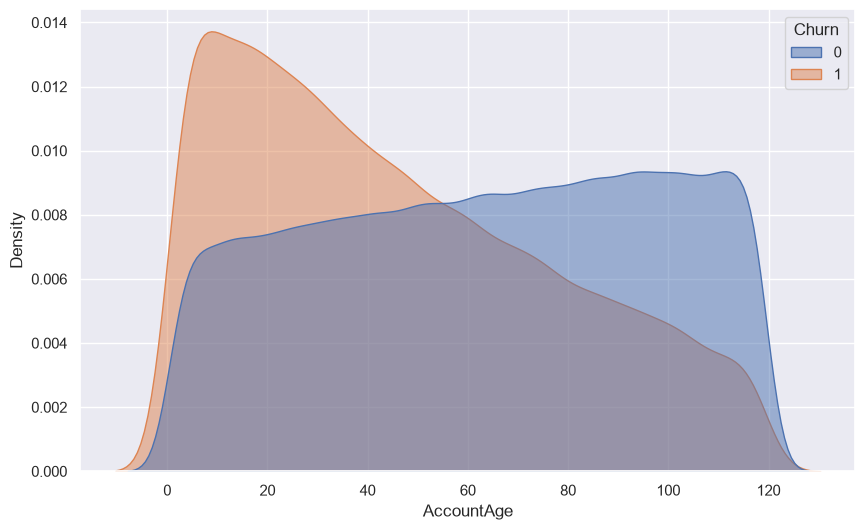

In [25]:
plt.figure(figsize=(10, 6)) 
sns.kdeplot(data=train_df, x='AccountAge', hue='Churn', fill=True, common_norm=False, alpha=0.5)
plt.show()

<Axes: xlabel='AccountAge', ylabel='Count'>

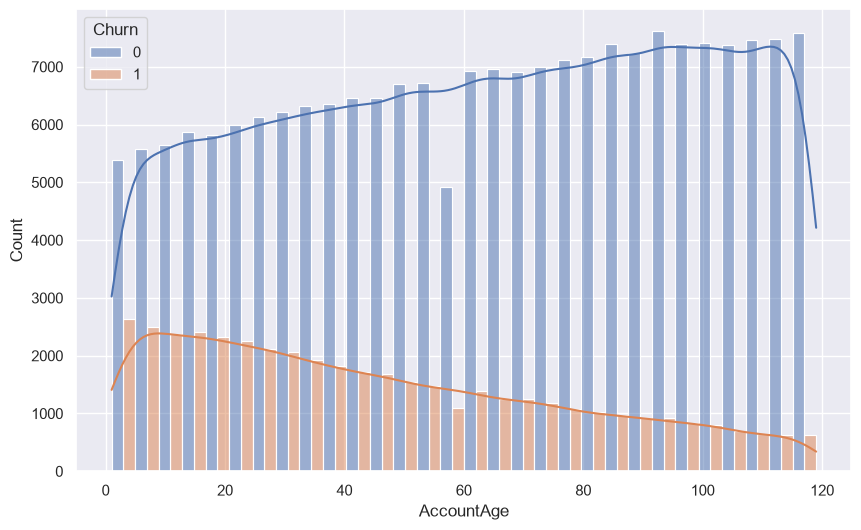

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='AccountAge', hue='Churn', multiple='dodge', bins=30, kde=True)

In [27]:
train_df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID', 'Churn'],
      dtype='str')

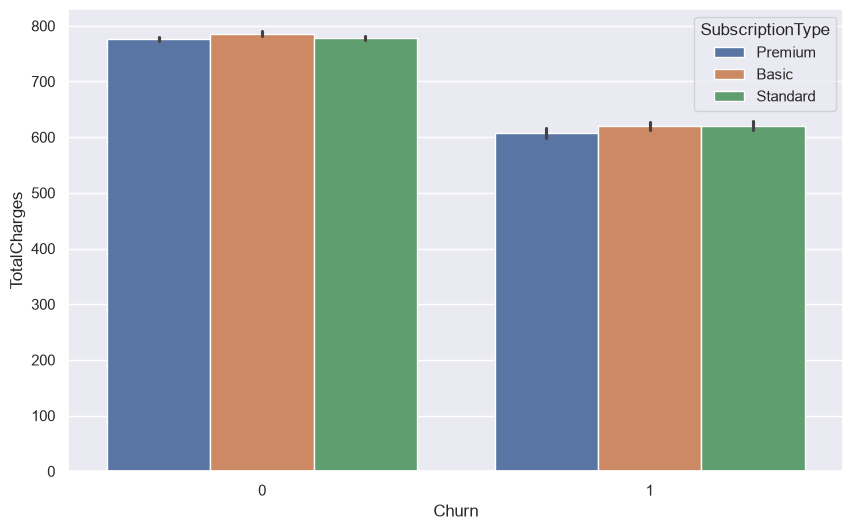

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='Churn', y='TotalCharges', hue='SubscriptionType')
plt.show()

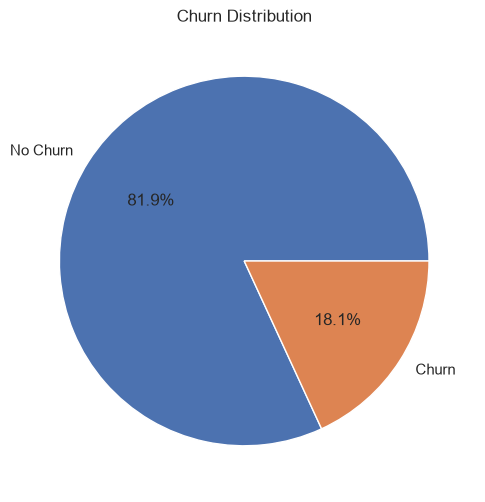

In [29]:
plt.figure(figsize=(12, 6))
plt.pie(train_df['Churn'].value_counts(), labels=['No Churn', 'Churn'], autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()

In [30]:
ct = pd.crosstab(train_df['SubscriptionType'], train_df['Churn'], normalize='index')
ct


Churn,0,1
SubscriptionType,,
Basic,0.803479,0.196521
Premium,0.837225,0.162775
Standard,0.815686,0.184314


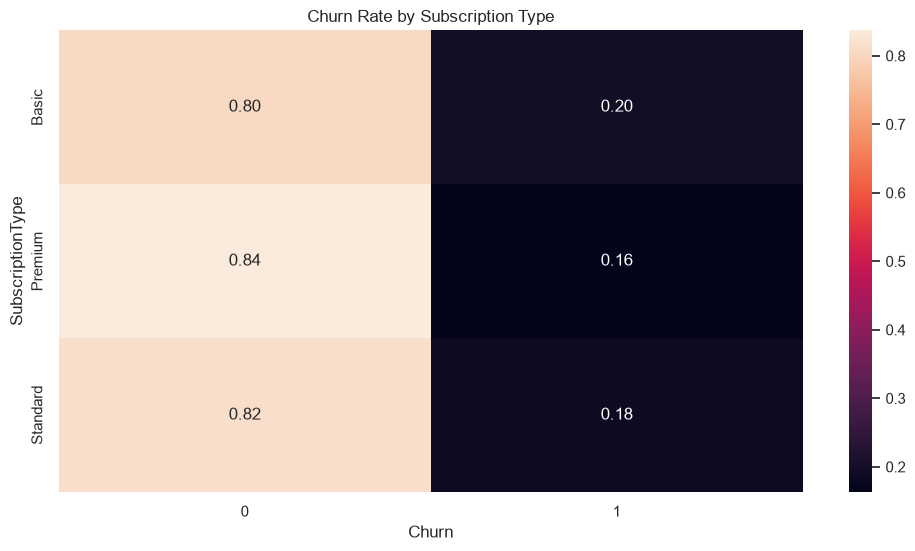

In [31]:
plt.figure(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt='.2f')
plt.title("Churn Rate by Subscription Type")
plt.show()

<Axes: ylabel='Frequency'>

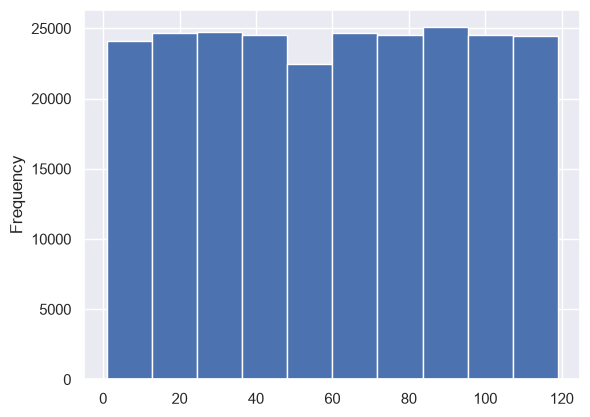

In [32]:
train_df["AccountAge"].skew()
train_df['AccountAge'].plot(kind='hist')

<Axes: xlabel='AccountAge', ylabel='TotalCharges'>

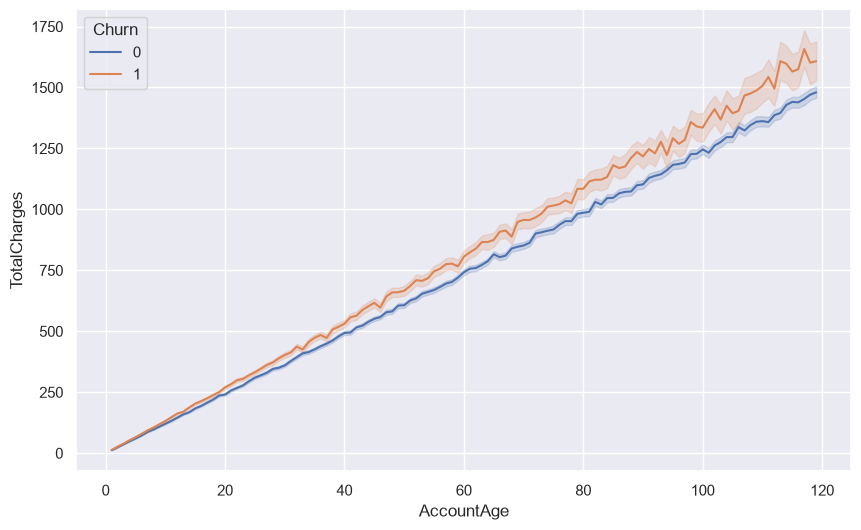

In [33]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='AccountAge', y='TotalCharges', hue='Churn')

In [34]:
train_df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID', 'Churn'],
      dtype='str')

<Axes: xlabel='ContentType', ylabel='count'>

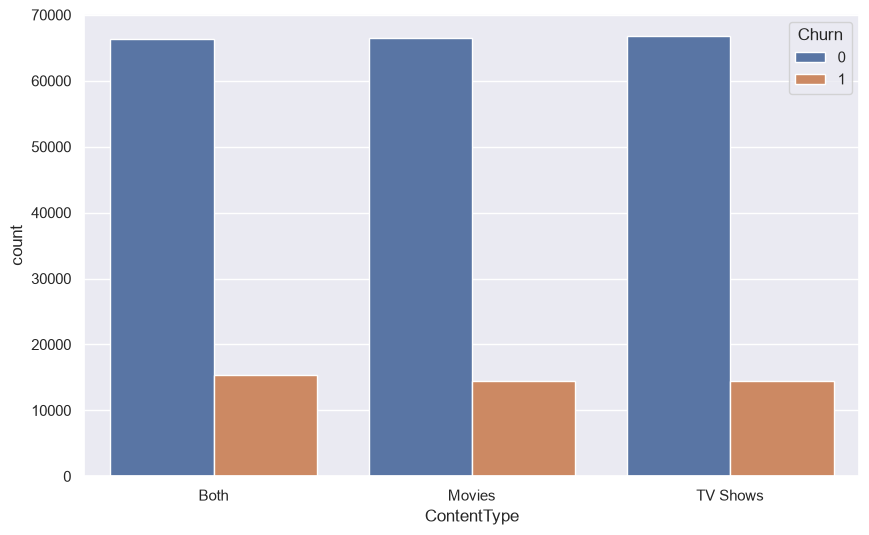

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='ContentType', hue='Churn')

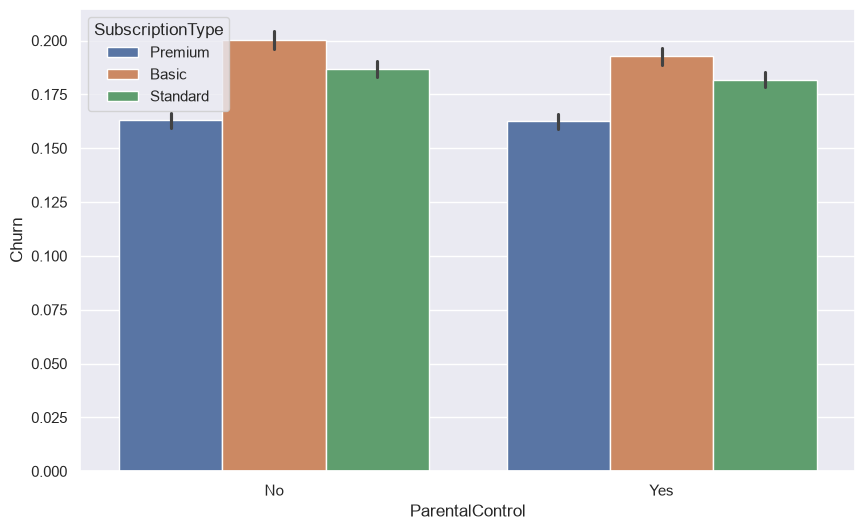

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='ParentalControl', y='Churn', hue='SubscriptionType')
plt.show()

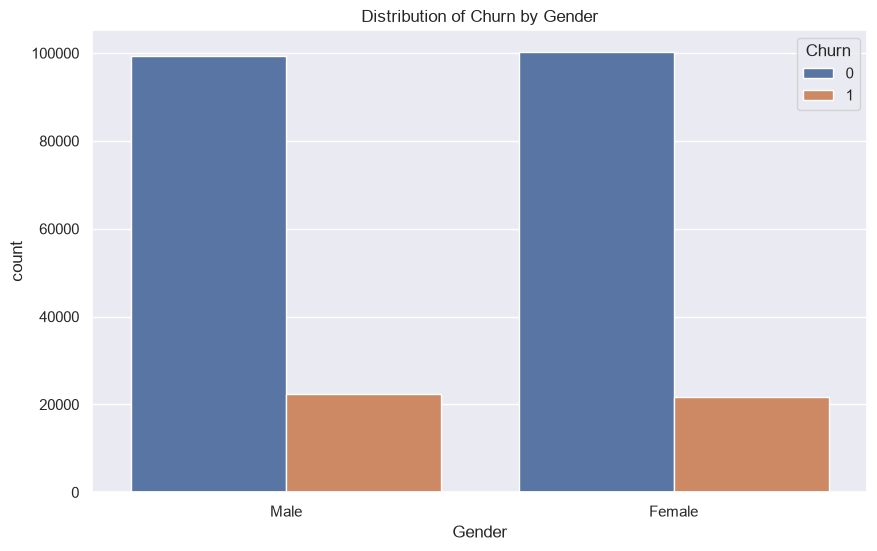

In [37]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='Gender', hue='Churn')
plt.title("Distribution of Churn by Gender")
plt.show()

In [38]:
train_df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'CustomerID', 'Churn'],
      dtype='str')

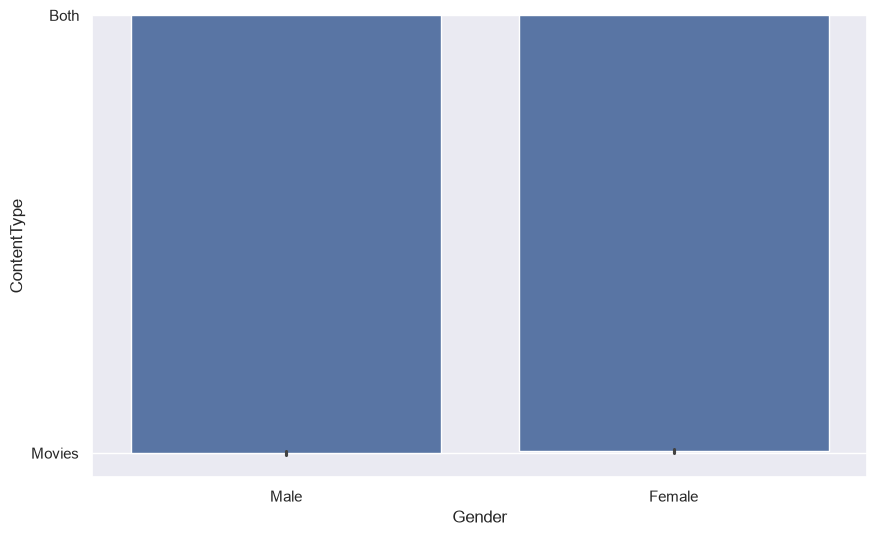

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='Gender', y='ContentType')
plt.show()

In [40]:
value_counts_user_rating = train_df["UserRating"].value_counts

In [41]:
value_counts_user_rating

<bound method IndexOpsMixin.value_counts of 0         2.176498
1         3.478632
2         4.238824
3         4.276013
4         3.616170
            ...   
243782    3.697451
243783    1.449742
243784    4.012217
243785    2.135789
243786    1.428896
Name: UserRating, Length: 243787, dtype: float64>

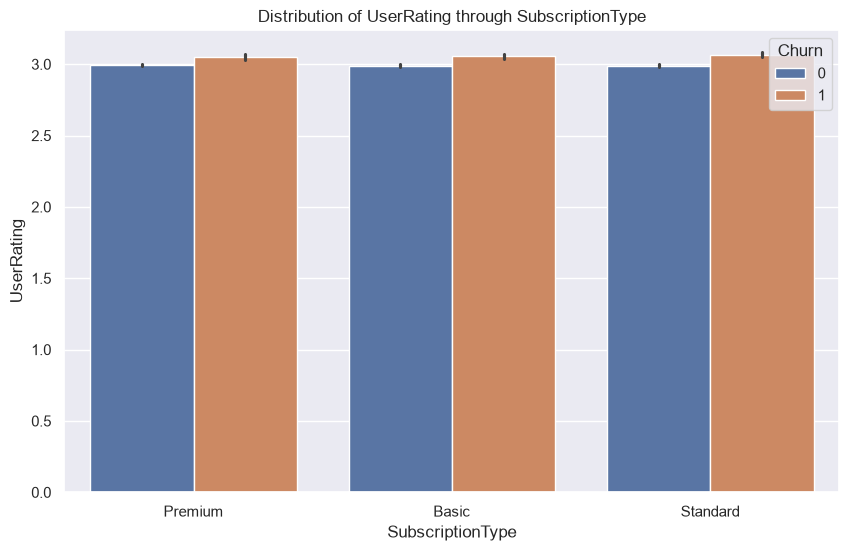

In [42]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='SubscriptionType', y='UserRating', hue='Churn')
plt.title("Distribution of UserRating through SubscriptionType")
plt.show()

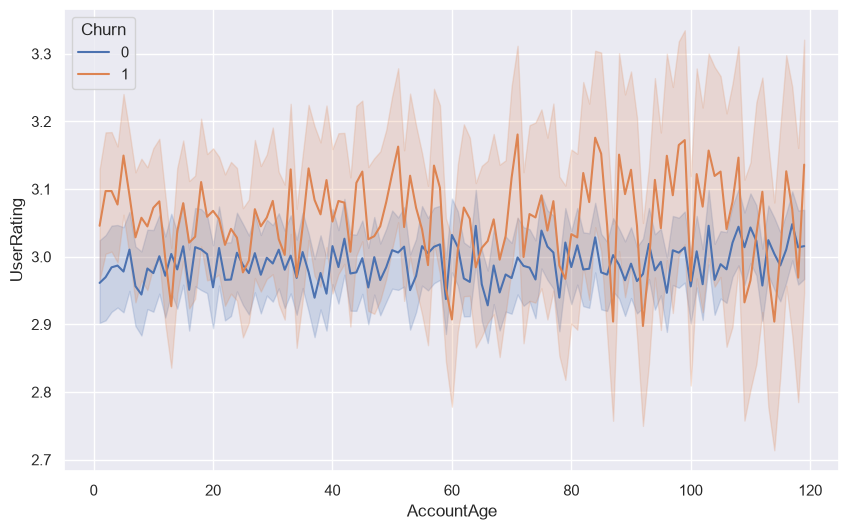

In [43]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='AccountAge', y='UserRating', hue='Churn')
plt.show()

In [44]:
corr_matrix = train_df.corr(numeric_only=True)

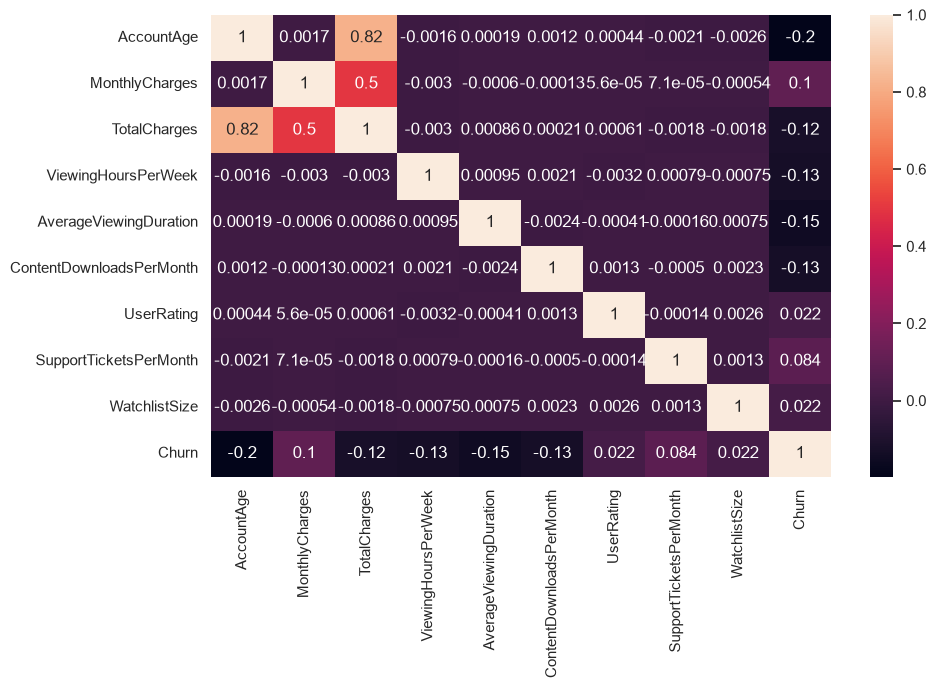

In [45]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [46]:
# Check high cardinality of Categorical features


nums_features = [feature for feature in train_df.columns if train_df[feature].dtypes in [int, float]]
cat_features = [feature for feature in train_df.columns if train_df[feature].dtypes not in [int, float]]

In [47]:
nums_features

['AccountAge',
 'MonthlyCharges',
 'TotalCharges',
 'ViewingHoursPerWeek',
 'AverageViewingDuration',
 'ContentDownloadsPerMonth',
 'UserRating',
 'SupportTicketsPerMonth',
 'WatchlistSize',
 'Churn']

In [48]:
cat_features

['SubscriptionType',
 'PaymentMethod',
 'PaperlessBilling',
 'ContentType',
 'MultiDeviceAccess',
 'DeviceRegistered',
 'GenrePreference',
 'Gender',
 'ParentalControl',
 'SubtitlesEnabled',
 'CustomerID']

In [49]:
def feature_value_count(df, feature):

    value_counts = df[feature].value_counts()
    print(f"------------{feature} value counts-------------\n")
    print(value_counts)
    print(f"-------------------------------------------------\n")

In [50]:
for feature in cat_features:
    feature_value_count(train_df, feature)

------------SubscriptionType value counts-------------

SubscriptionType
Standard    81920
Basic       81050
Premium     80817
Name: count, dtype: int64
-------------------------------------------------

------------PaymentMethod value counts-------------

PaymentMethod
Electronic check    61313
Credit card         60924
Bank transfer       60797
Mailed check        60753
Name: count, dtype: int64
-------------------------------------------------

------------PaperlessBilling value counts-------------

PaperlessBilling
No     121980
Yes    121807
Name: count, dtype: int64
-------------------------------------------------

------------ContentType value counts-------------

ContentType
Both        81737
TV Shows    81145
Movies      80905
Name: count, dtype: int64
-------------------------------------------------

------------MultiDeviceAccess value counts-------------

MultiDeviceAccess
No     122035
Yes    121752
Name: count, dtype: int64
-----------------------------------------------

### High Cardinality of Categorical Features

- One feature is high cardinality which is __CustomerID__

In [51]:
train_df['Churn'].value_counts()

Churn
0    199605
1     44182
Name: count, dtype: int64

- __Churn__ feature somehow have imbalance with 0 with 1.99K and 1 with 44K

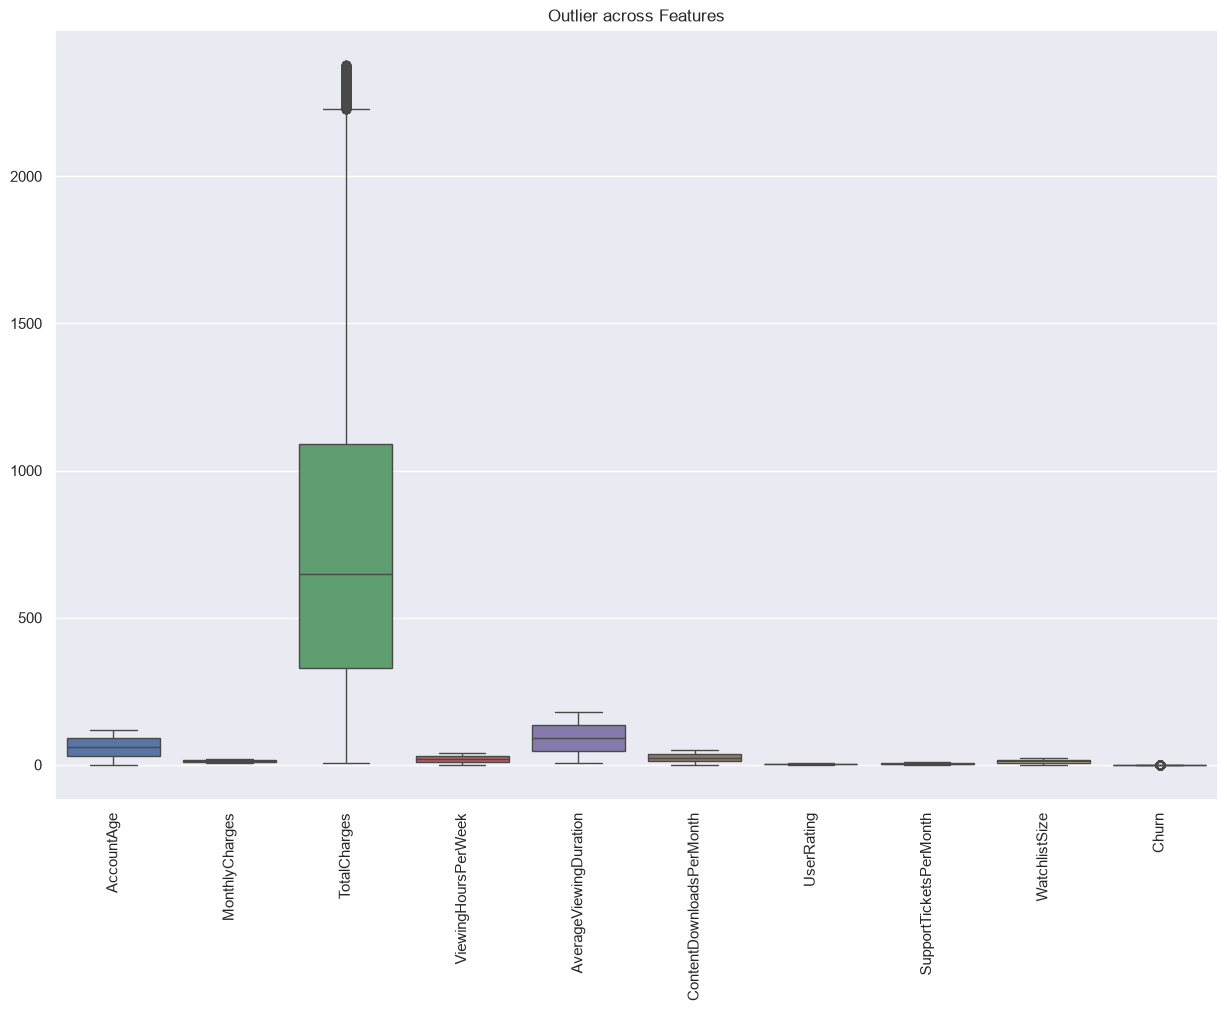

In [52]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=train_df)
plt.title("Outlier across Features")
plt.xticks(rotation=90)
plt.show()

- __totalCharges__ have outliers in feature

In [53]:
import math
def target_rate_by_feature(df, features, target='Churn', n_cols=3, figsize=(16, 20)):

    n_features = len(features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[1]

        rate = df.groupby(feature)[target].mean().sort_values(ascending=False)

        # Plot
        rate.plot(kind="bar", ax=ax, edgecolor='black')
        ax.set_title(f"Target Rate by {feature}")
        ax.set_ylabel("Target Rate")
        ax.tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    

In [54]:
target_rate_by_subscription = train_df.groupby("SubscriptionType")["Churn"].mean().sort_values(ascending=False)

In [55]:
target_rate_by_subscription

SubscriptionType
Basic       0.196521
Standard    0.184314
Premium     0.162775
Name: Churn, dtype: float64

Text(0.5, 1.0, 'Target Rate by SubscriptionType')

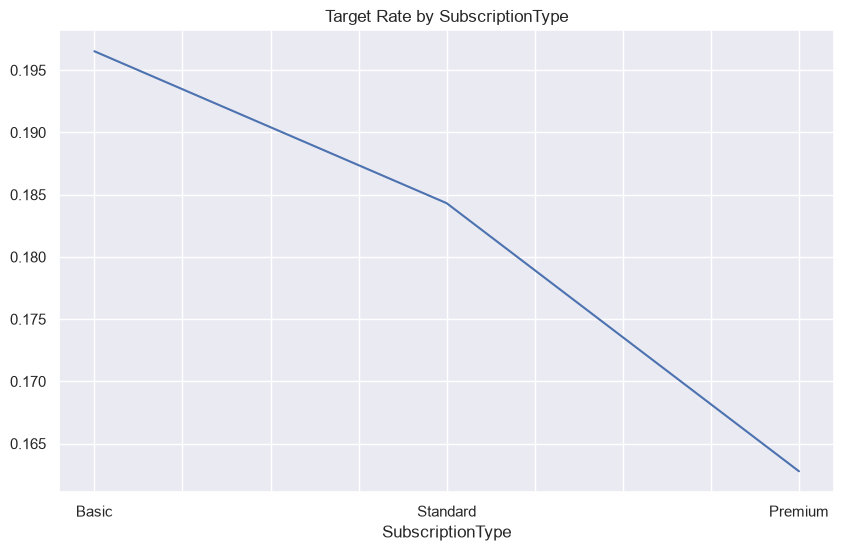

In [56]:
plt.figure(figsize=(10, 6))
target_rate_by_subscription.plot(kind='line')
plt.title("Target Rate by SubscriptionType")

In [57]:
def target_rate_by_feature2(df, feature, target='Churn'):

    rate = df.groupby(feature)[target].mean().sort_values(ascending=False)

    print(f"-------------\n")
    print(rate)
    print(f"--------------\n")

In [58]:
for feature in train_df.columns:
    target_rate_by_feature2(df=train_df, feature=feature)

-------------

AccountAge
4      0.340237
1      0.328536
5      0.323335
3      0.322404
2      0.321991
         ...   
115    0.074864
119    0.074843
111    0.074641
118    0.072211
113    0.069849
Name: Churn, Length: 119, dtype: float64
--------------

-------------

MonthlyCharges
14.616344    1.0
7.769040     1.0
11.264514    1.0
7.769336     1.0
11.264312    1.0
            ... 
10.326975    0.0
10.326978    0.0
10.327003    0.0
10.327114    0.0
10.325844    0.0
Name: Churn, Length: 243787, dtype: float64
--------------

-------------

TotalCharges
2356.614662    1.0
2354.568689    1.0
5.206657       1.0
5.197155       1.0
5.186170       1.0
              ... 
5.113740       0.0
5.108220       0.0
5.104618       0.0
5.101684       0.0
5.097032       0.0
Name: Churn, Length: 243787, dtype: float64
--------------

-------------

SubscriptionType
Basic       0.196521
Standard    0.184314
Premium     0.162775
Name: Churn, dtype: float64
--------------

-------------

PaymentMethod

Text(0.5, 1.0, 'Target Rate by AccountAge')

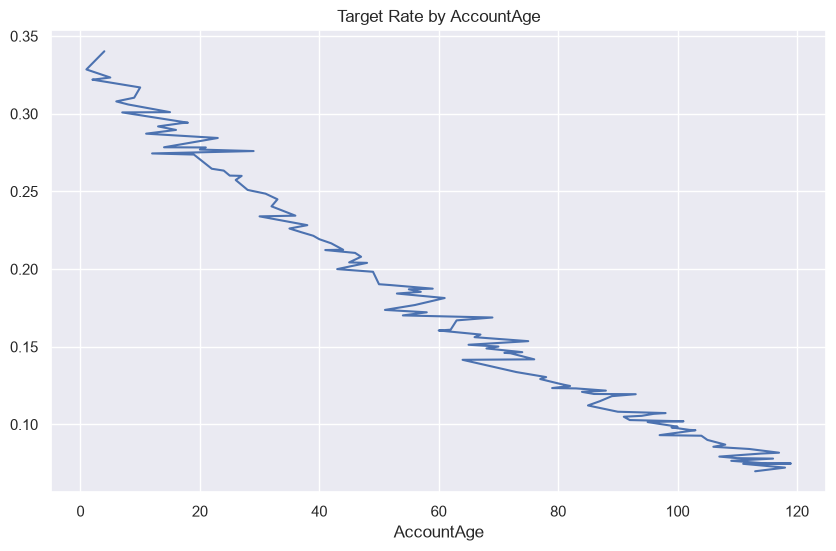

In [59]:
rate_by_accountage = train_df.groupby("AccountAge")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rate_by_accountage.plot(kind='line')
plt.title("Target Rate by AccountAge")

In [61]:
train_df.groupby("AccountAge")["Churn"].mean().sum()

np.float64(21.596546891659152)

In [75]:
def target_rate_by_feature3(df, features, target='Churn'):

    for feature in features:
        rate = df.groupby(feature)[target].mean().sort_values(ascending=False)
        print(f"Target Rate by {feature}: {rate}")
        print("\n")
        print(f"____________________________")      

In [76]:
target_rate_by_feature3(train_df, features=train_df.columns, target='Churn')

Target Rate by AccountAge: AccountAge
4      0.340237
1      0.328536
5      0.323335
3      0.322404
2      0.321991
         ...   
115    0.074864
119    0.074843
111    0.074641
118    0.072211
113    0.069849
Name: Churn, Length: 119, dtype: float64


____________________________


Target Rate by MonthlyCharges: MonthlyCharges
14.616344    1.0
7.769040     1.0
11.264514    1.0
7.769336     1.0
11.264312    1.0
            ... 
10.326975    0.0
10.326978    0.0
10.327003    0.0
10.327114    0.0
10.325844    0.0
Name: Churn, Length: 243787, dtype: float64


____________________________
Target Rate by TotalCharges: TotalCharges
2356.614662    1.0
2354.568689    1.0
5.206657       1.0
5.197155       1.0
5.186170       1.0
              ... 
5.113740       0.0
5.108220       0.0
5.104618       0.0
5.101684       0.0
5.097032       0.0
Name: Churn, Length: 243787, dtype: float64


____________________________
Target Rate by SubscriptionType: SubscriptionType
Basic       0.196521
Standard    0.184314
Premium     0.162775
Name: Churn, dtype: float64


____________________________
Target Rate by PaymentMethod: PaymentMethod
Electronic check    0.192471
Mailed check        0.190888
Bank transfer       0.179269
Credit card         0.162251
Name: Churn, dtype: float64


____

In [77]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

def mutual_information(df, target='Churn'):

    X = df.drop(columns=[target]).copy()
    y = df[target]

    # Encode Categorical columns
    for feature in cat_features:
        X[feature] = LabelEncoder().fit_transform(X[feature].astype(str))

    X = X.fillna(-999)

    ml_scores = mutual_info_classif(X, y, random_state=42)

    ml_df = pd.DataFrame({
        "Feature": X.columns,
        "Mutual_information": ml_scores
    }).sort_values(by='Mutual_information', ascending=False)

    return ml_df

In [78]:
mi_scores = mutual_information(train_df, target='Churn')

In [79]:
mi_scores

,Feature,Mutual_information
18,SubtitlesEnabled,0.029627
17,ParentalControl,0.029433
7,MultiDeviceAccess,0.028818
5,PaperlessBilling,0.028332
15,Gender,0.027822
0,AccountAge,0.020423
3,SubscriptionType,0.015444
6,ContentType,0.014820
10,AverageViewingDuration,0.009994
11,ContentDownloadsPerMonth,0.009760


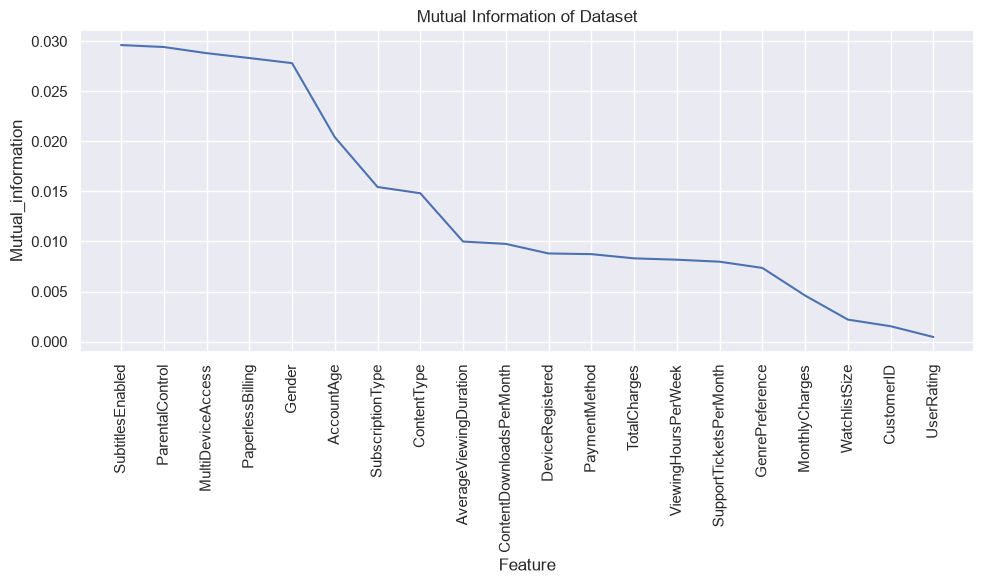

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=mi_scores, x='Feature', y='Mutual_information')
plt.title("Mutual Information of Dataset")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### EDA Summary 

- No missing value
- No duplicate values
- UserRating and CustomerID have low mutual information score